In [1]:
import sys
print(sys.executable)

/home/adriano/doc/projects/data_science/data_science_classification/.venv/bin/python


In [3]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn theme for plots
sns.set_theme(style='whitegrid')

# Load the Telco Churn CSV
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Show dataset shape (rows, columns)
print(df.shape)

# Show target distribution (churn rate)
print(df['Churn'].value_counts(normalize=True))

# Show first rows
print(df.head())

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...    

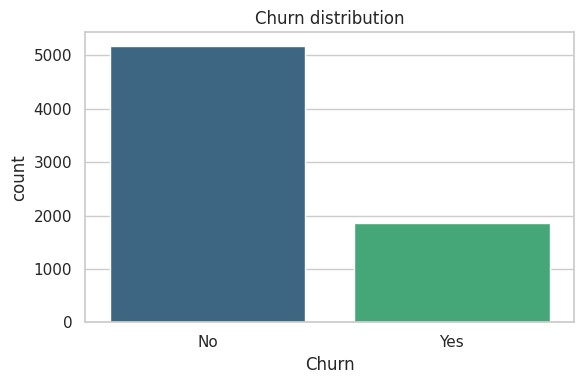

In [5]:
# Distribution of the target variable (churn vs no churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Churn distribution')
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150)
plt.show()

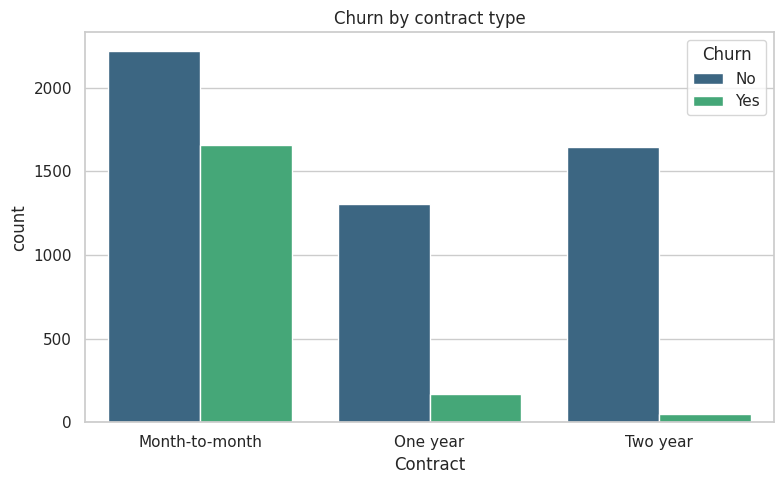

In [6]:
# Churn rate by contract type
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Churn by contract type')
plt.tight_layout()
plt.savefig('churn_by_contract.png', dpi=150)
plt.show()

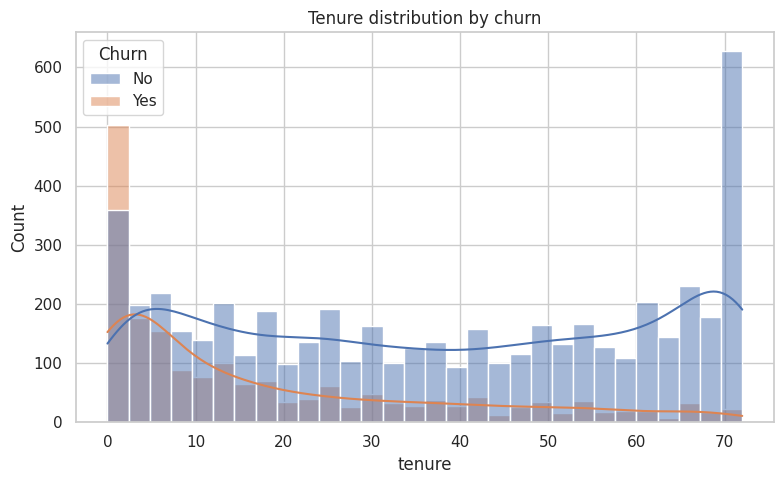

In [7]:
# Distribution of tenure (months as customer) split by churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure distribution by churn')
plt.tight_layout()
plt.savefig('churn_by_tenure.png', dpi=150)
plt.show()

In [8]:
# Convert Churn to binary for correlation
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

# Select only numeric columns
numeric = df.select_dtypes(include=[np.number])

# Compute correlation with the target
corr = numeric.corr()['Churn_bin'].sort_values(ascending=False)
print(corr)

Churn_bin         1.000000
MonthlyCharges    0.193356
SeniorCitizen     0.150889
tenure           -0.352229
Name: Churn_bin, dtype: float64
